# Desafío: Causalidad, Correlación y Coeficientes de Asociación — SOLUCIÓN
### Minería de Datos — Unidad 2: Preparación de la Información

> **Nota:** este notebook es la pauta de solución del desafío, con las celdas `TODO` completas y las preguntas respondidas a modo de ejemplo. Las respuestas de los estudiantes pueden variar en redacción; lo relevante es que sus conclusiones sean consistentes con los valores que obtuvieron.

---

## Contexto

Su equipo trabaja como analista de datos para el departamento de estudios de una ciudad. La municipalidad quiere entender cómo la **temperatura durante el verano** se relaciona con distintos indicadores urbanos: consumo energético, precipitaciones, ventas de helados, casos de golpe de calor, calidad del aire y población por comuna.

El conjunto de datos fue construido para poner en práctica **todos los conceptos revisados en la Guía N.º 1**: no todas las relaciones son igual de creíbles, y una de ellas esconde una correlación espuria que debe detectarse y explicarse.

## Objetivos del desafío

- Distinguir causalidad de correlación e identificar una correlación espuria dentro del propio dataset.
- Explorar relaciones entre variables mediante diagramas de dispersión.
- Calcular e interpretar los coeficientes de correlación de Pearson, Spearman y Kendall, justificando en cada caso cuál corresponde usar.
- Clasificar la magnitud de una correlación según la tabla de interpretación revisada en la guía.
- Evaluar la significancia estadística de una correlación mediante su p-valor.
- Construir e interpretar una matriz de correlación completa.

## Instrucciones generales

1. Ejecuten las celdas de la sección **Parte 0** y **Parte 1** tal como están: preparan el entorno y generan el dataset de trabajo.
2. En las secciones siguientes encontrarán celdas de código marcadas con `# TODO`: deben completarlas ustedes.
3. Cada sección incluye una o más preguntas en celdas de markdown (`**Respuesta:**`) que deben responder con sus propias palabras, basándose en los resultados que obtuvieron.
4. No es necesario usar código adicional fuera de lo pedido, pero pueden agregar celdas propias si lo consideran útil para su análisis.
5. Al final encontrarán una lista de verificación: revísenla antes de entregar.

## Parte 0 — Preparación del entorno

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid")
pd.set_option("display.precision", 2)


## Parte 1 — El dataset

Trabajarán con un dataset simulado de **150 registros diarios de verano**, uno por comuna/día, con las siguientes variables:

| Variable | Descripción | Tipo |
| --- | --- | --- |
| `Temperatura_C` | Temperatura promedio del día (°C) | Numérica continua |
| `Consumo_Energia_kWh` | Consumo energético residencial del día (kWh) | Numérica continua |
| `Precipitaciones_mm` | Precipitaciones registradas (mm) | Numérica continua |
| `Ventas_Helados_unid` | Unidades de helados vendidas en la comuna | Numérica discreta |
| `Casos_GolpeCalor` | Casos de golpe de calor atendidos en centros de salud | Numérica discreta |
| `Poblacion_Comuna_miles` | Población de la comuna (miles de habitantes) | Numérica continua |
| `Nivel_Calidad_Aire` | Índice de calidad del aire (1 = buena, 5 = muy mala) | Ordinal |

Ejecuten la siguiente celda para generar el dataset (no necesitan modificarla).

In [2]:
rng = np.random.default_rng(42)
n = 150

# Variable base: temperatura promedio diaria (°C)
temperatura = np.clip(rng.normal(loc=27, scale=4, size=n), 15, 38)

# Consumo energético: fuertemente relacionado con la temperatura (uso de aire acondicionado)
consumo_energia = 120 + 18 * temperatura + rng.normal(0, 40, n)
outlier_idx = rng.choice(n, size=4, replace=False)
consumo_energia[outlier_idx] += rng.choice([600, -500], size=4)  # outliers deliberados

# Precipitaciones: relación negativa moderada con la temperatura
precipitaciones = np.clip(140 - 3.2 * temperatura + rng.normal(0, 25, n), 0, None)

# Ventas de helados: fuertemente relacionadas con la temperatura
ventas_helados = np.clip(50 + 24 * temperatura + rng.normal(0, 45, n), 0, None).round(0)

# Casos de golpe de calor: fuertemente relacionados con la temperatura (independientes de las ventas de helados)
casos_golpe_calor = np.clip(-8 + 0.95 * temperatura + rng.normal(0, 2.0, n), 0, None).round(0)

# Población de la comuna: sin relación con la temperatura (variable de control)
poblacion_comuna = np.clip(rng.normal(85, 20, n), 20, None).round(1)

# Nivel de calidad del aire (ordinal 1-5): empeora con la temperatura
prop_temp = (temperatura - temperatura.min()) / (temperatura.max() - temperatura.min())
nivel_calidad_aire = np.clip(np.round(1 + 4 * prop_temp + rng.normal(0, 0.6, n)), 1, 5).astype(int)

df = pd.DataFrame({
    "Temperatura_C": temperatura.round(1),
    "Consumo_Energia_kWh": consumo_energia.round(1),
    "Precipitaciones_mm": precipitaciones.round(1),
    "Ventas_Helados_unid": ventas_helados.astype(int),
    "Casos_GolpeCalor": casos_golpe_calor.astype(int),
    "Poblacion_Comuna_miles": poblacion_comuna,
    "Nivel_Calidad_Aire": nivel_calidad_aire,
})

df.head()


,Temperatura_C,Consumo_Energia_kWh,Precipitaciones_mm,Ventas_Helados_unid,Casos_GolpeCalor,Poblacion_Comuna_miles,Nivel_Calidad_Aire
0,28.2,621.6,41.3,776,20,66.6,3
1,22.8,489.7,99.4,560,15,102.1,1
2,30.0,593.0,58.6,785,17,97.8,3
3,30.8,654.3,84.9,787,22,93.9,3
4,19.2,463.4,108.0,525,8,110.0,1


In [3]:
df.describe()


,Temperatura_C,Consumo_Energia_kWh,Precipitaciones_mm,Ventas_Helados_unid,Casos_GolpeCalor,Poblacion_Comuna_miles,Nivel_Calidad_Aire
count,150.00,150.00,150.00,150.00,150.00,150.00,150.00
mean,26.79,617.02,55.98,689.68,17.25,84.23,2.69
std,3.41,124.74,27.04,88.85,3.80,19.90,0.91
min,18.50,426.60,0.00,502.00,8.00,31.50,1.00
25%,24.40,550.45,37.40,630.25,15.00,71.72,2.00
50%,26.85,607.95,58.60,688.00,17.00,85.25,3.00
75%,29.08,653.10,74.95,753.75,20.00,94.42,3.00
max,38.00,1267.50,114.20,943.00,30.00,148.60,5.00


## Parte 2 — Exploración visual: diagramas de dispersión

Antes de calcular cualquier coeficiente, exploren visualmente las relaciones entre variables.

**TODO:** generen diagramas de dispersión para **al menos 4 pares de variables** que les parezcan potencialmente relacionados (pueden usar `sns.pairplot` sobre un subconjunto de columnas, o `plt.scatter` par por par).

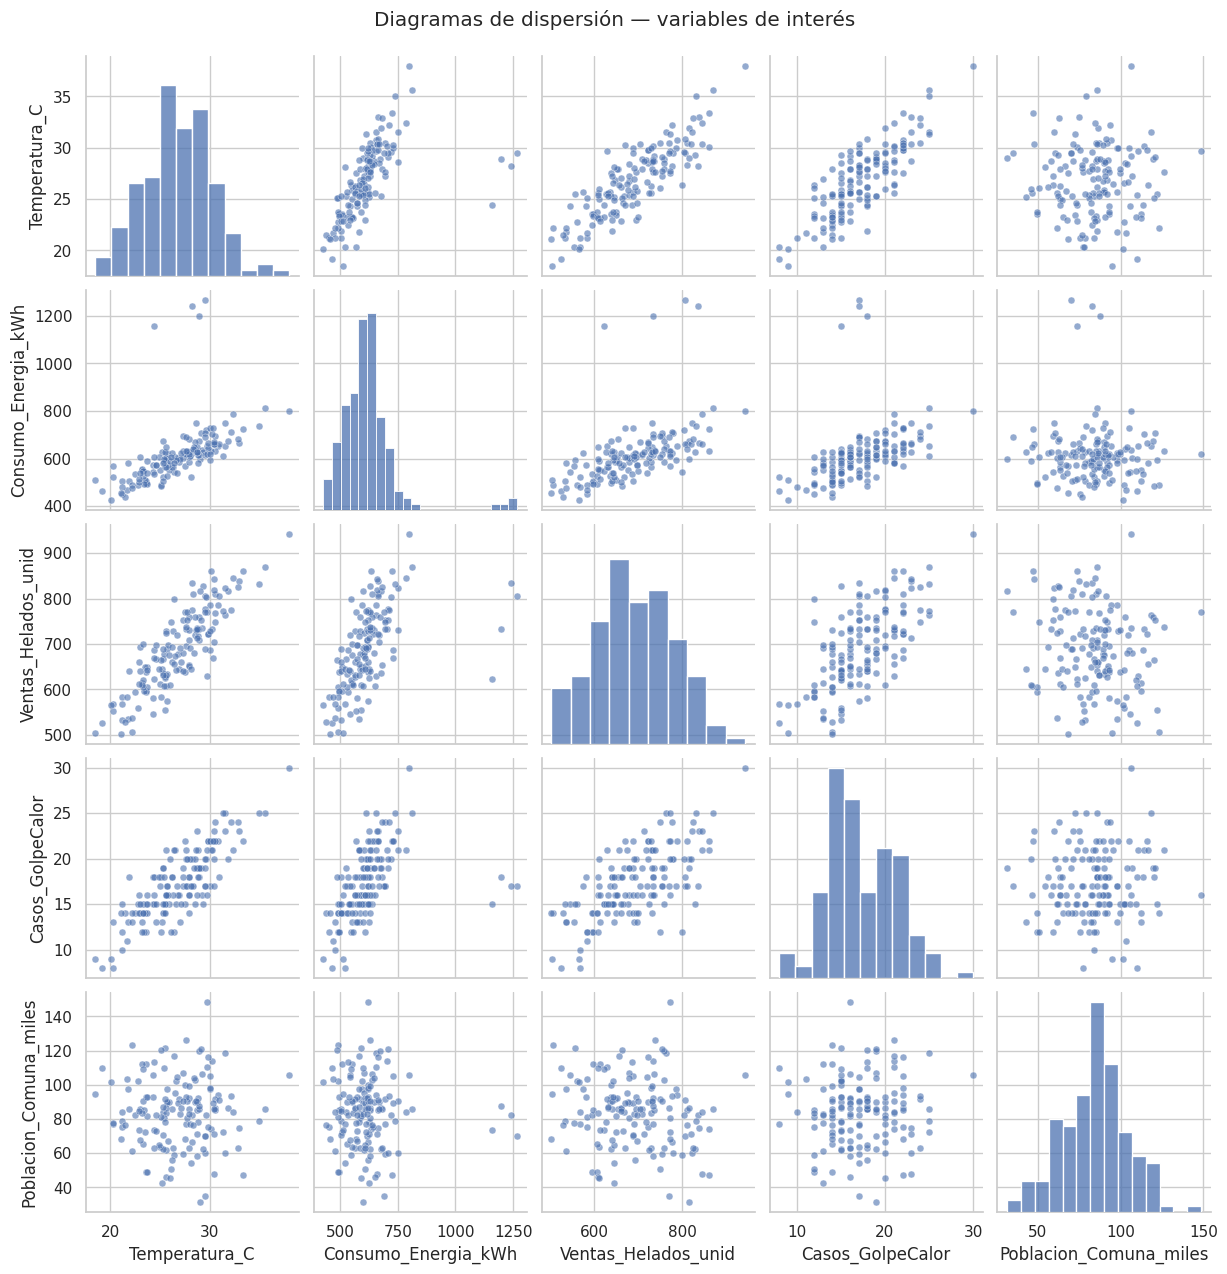

In [4]:
variables_interes = [
    "Temperatura_C",
    "Consumo_Energia_kWh",
    "Ventas_Helados_unid",
    "Casos_GolpeCalor",
    "Poblacion_Comuna_miles",
]
sns.pairplot(df[variables_interes], diag_kind="hist", plot_kws={"alpha": 0.6, "s": 25})
plt.suptitle("Diagramas de dispersión — variables de interés", y=1.02)
plt.show()


**Pregunta 2.1:** ¿Qué pares de variables muestran una relación visualmente clara? ¿La relación parece positiva, negativa o nula? ¿Alguna les pareció no lineal?

**Respuesta:** `Temperatura_C` muestra una relación positiva y visualmente clara con `Ventas_Helados_unid` y con `Casos_GolpeCalor`: en ambos casos la nube de puntos sube de izquierda a derecha y se ve razonablemente lineal. `Consumo_Energia_kWh` también sube con la temperatura, pero la nube está más dispersa y se notan un par de puntos muy alejados del resto (outliers) que se salen claramente de la tendencia. `Ventas_Helados_unid` y `Casos_GolpeCalor` entre sí también muestran una relación positiva, aunque un poco más dispersa que cada una por separado con la temperatura. En cambio, `Poblacion_Comuna_miles` no muestra ningún patrón claro con ninguna otra variable: la nube de puntos se ve como una nube sin forma (aleatoria) en todos los paneles donde aparece.

## Parte 3 — Coeficientes de correlación

Calculen el coeficiente de correlación más adecuado para cada uno de los siguientes pares, **justificando en cada caso** por qué eligieron Pearson, Spearman o Kendall (tipo de variable, presencia de outliers, linealidad de la relación).

**a)** `Temperatura_C` vs. `Consumo_Energia_kWh` — calculen **tanto Pearson como Spearman** y comparen los resultados. Recuerden que esta variable contiene outliers deliberados.

**b)** `Temperatura_C` vs. `Nivel_Calidad_Aire` — `Nivel_Calidad_Aire` es una variable ordinal.

**c)** `Ventas_Helados_unid` vs. `Casos_GolpeCalor`.

**d)** `Poblacion_Comuna_miles` vs. `Temperatura_C`.

Para cada cálculo, usen `scipy.stats.pearsonr`, `scipy.stats.spearmanr` o `scipy.stats.kendalltau`: las tres funciones retornan el coeficiente **y** el p-valor en un mismo paso, que usarán también en la Parte 5.

In [5]:
# a) Temperatura_C vs Consumo_Energia_kWh — Pearson y Spearman
r_pearson_a, p_pearson_a = stats.pearsonr(df["Temperatura_C"], df["Consumo_Energia_kWh"])
r_spearman_a, p_spearman_a = stats.spearmanr(df["Temperatura_C"], df["Consumo_Energia_kWh"])

print(f"Pearson:  r = {r_pearson_a:.3f}  (p = {p_pearson_a:.5f})")
print(f"Spearman: rs = {r_spearman_a:.3f}  (p = {p_spearman_a:.5f})")


Pearson:  r = 0.548  (p = 0.00000)
Spearman: rs = 0.820  (p = 0.00000)


In [6]:
# b) Temperatura_C vs Nivel_Calidad_Aire — Nivel_Calidad_Aire es ordinal, así que Spearman es más apropiado que Pearson
r_spearman_b, p_spearman_b = stats.spearmanr(df["Temperatura_C"], df["Nivel_Calidad_Aire"])

print(f"Spearman: rs = {r_spearman_b:.3f}  (p = {p_spearman_b:.5f})")


Spearman: rs = 0.736  (p = 0.00000)


In [7]:
# c) Ventas_Helados_unid vs Casos_GolpeCalor — ambas cuantitativas discretas, relación aproximadamente lineal y sin outliers evidentes: Pearson
r_pearson_c, p_pearson_c = stats.pearsonr(df["Ventas_Helados_unid"], df["Casos_GolpeCalor"])

print(f"Pearson: r = {r_pearson_c:.3f}  (p = {p_pearson_c:.5f})")


Pearson: r = 0.676  (p = 0.00000)


In [8]:
# d) Poblacion_Comuna_miles vs Temperatura_C — ambas cuantitativas continuas, sin outliers relevantes: Pearson
r_pearson_d, p_pearson_d = stats.pearsonr(df["Poblacion_Comuna_miles"], df["Temperatura_C"])

print(f"Pearson: r = {r_pearson_d:.3f}  (p = {p_pearson_d:.5f})")


Pearson: r = -0.009  (p = 0.91049)


**Pregunta 3.1:** Para el par a), ¿el coeficiente de Pearson y el de Spearman entregan resultados similares o distintos? ¿Cómo explican esa diferencia (o similitud) considerando los outliers?

**Respuesta:** Son bastante distintos: Pearson da r ≈ 0.55 (moderado), mientras que Spearman da rs ≈ 0.82 (fuerte). Esto se explica porque Pearson trabaja directamente con los valores de las variables, por lo que los outliers que se agregaron deliberadamente a `Consumo_Energia_kWh` "tiran" la recta de ajuste y reducen el coeficiente. Spearman, en cambio, trabaja con los rangos (el orden) de las observaciones, por lo que unos pocos valores extremos no alteran tanto el resultado. Esto confirma que, cuando hay outliers, Spearman entrega una medida más robusta de la verdadera fuerza de la asociación.

**Pregunta 3.2:** ¿Por qué eligieron el coeficiente que usaron en b)? ¿Qué habría pasado si hubiesen usado Pearson en su lugar?

**Respuesta:** Se usó Spearman porque `Nivel_Calidad_Aire` es una variable ordinal (categorías 1 a 5 con un orden, pero sin que la distancia entre categorías sea necesariamente uniforme): Spearman mide la asociación a partir del orden de los datos, que es justamente el tipo de información que tiene sentido para una variable ordinal. Pearson asume que las variables son cuantitativas y que la relación es lineal en sus valores numéricos; usarlo con una variable ordinal trataría las categorías como si fueran cantidades exactas, lo que puede distorsionar la medida de asociación. En este caso particular el resultado de Pearson (r ≈ 0.73) es parecido al de Spearman (rs ≈ 0.74), pero eso no siempre ocurre, y Spearman sigue siendo la elección metodológicamente correcta.

## Parte 4 — Interpretación de la magnitud

Recuerden la tabla de interpretación de la Guía N.º 1:

| Rango (valor absoluto) | Interpretación |
| --- | --- |
| 0.9 a 1.0 | Muy fuerte |
| 0.7 a 0.9 | Fuerte |
| 0.5 a 0.7 | Moderada |
| 0.3 a 0.5 | Débil |
| 0 a 0.3 | Despreciable |

La siguiente función implementa esta tabla — pueden usarla para clasificar cualquier coeficiente que calculen, sin repetir la lógica a mano cada vez.

In [9]:
def interpretar_correlacion(valor):
    '''Clasifica la magnitud y dirección de un coeficiente de correlación.'''
    v = abs(valor)
    if v >= 0.9:
        fuerza = "muy fuerte"
    elif v >= 0.7:
        fuerza = "fuerte"
    elif v >= 0.5:
        fuerza = "moderada"
    elif v >= 0.3:
        fuerza = "débil"
    else:
        fuerza = "despreciable"
    if v < 0.3:
        return f"{fuerza} (prácticamente sin relación lineal)"
    direccion = "positiva" if valor > 0 else "negativa"
    return f"{fuerza} y {direccion}"


In [10]:
print("a) Temp vs Consumo (Pearson): ", interpretar_correlacion(r_pearson_a))
print("a) Temp vs Consumo (Spearman):", interpretar_correlacion(r_spearman_a))
print("b) Temp vs CalidadAire:       ", interpretar_correlacion(r_spearman_b))
print("c) Helados vs GolpeCalor:     ", interpretar_correlacion(r_pearson_c))
print("d) Poblacion vs Temp:         ", interpretar_correlacion(r_pearson_d))


a) Temp vs Consumo (Pearson):  moderada y positiva
a) Temp vs Consumo (Spearman): fuerte y positiva
b) Temp vs CalidadAire:        fuerte y positiva
c) Helados vs GolpeCalor:      moderada y positiva
d) Poblacion vs Temp:          despreciable (prácticamente sin relación lineal)


**Pregunta 4.1:** Según esta clasificación, ¿cuál de los cuatro pares analizados tiene la relación más fuerte y cuál la más débil?

**Respuesta:** La relación más fuerte es la del par b), `Temperatura_C` vs. `Nivel_Calidad_Aire` (rs ≈ 0.74, fuerte), seguida de cerca por c) `Ventas_Helados_unid` vs. `Casos_GolpeCalor` (r ≈ 0.68, moderada) y por a) usando Spearman (rs ≈ 0.82, fuerte). La relación más débil —de hecho, despreciable— es d), `Poblacion_Comuna_miles` vs. `Temperatura_C` (r ≈ -0.01), consistente con que esta variable fue diseñada como variable de control sin relación con el resto.

## Parte 5 — Significancia estadística

Un coeficiente calculado sobre una muestra podría deberse al azar. Usen el p-valor que ya obtuvieron en la Parte 3 (segundo valor retornado por `pearsonr`, `spearmanr` o `kendalltau`) para evaluar, con un nivel de significancia de 0.05, si cada correlación es estadísticamente significativa.

La siguiente función automatiza la decisión de la prueba de hipótesis (H0: ρ = 0 vs. H1: ρ ≠ 0).

In [11]:
def evaluar_significancia(p_valor, alpha=0.05):
    '''Evalúa la prueba de hipótesis H0: rho = 0 vs H1: rho != 0.'''
    if p_valor < alpha:
        return f"p-valor = {p_valor:.4f} < {alpha} → se rechaza H0: la correlación es estadísticamente significativa."
    else:
        return f"p-valor = {p_valor:.4f} >= {alpha} → no se rechaza H0: no hay evidencia suficiente de correlación."


In [12]:
print("a) Temp vs Consumo (Pearson): ", evaluar_significancia(p_pearson_a))
print("a) Temp vs Consumo (Spearman):", evaluar_significancia(p_spearman_a))
print("b) Temp vs CalidadAire:       ", evaluar_significancia(p_spearman_b))
print("c) Helados vs GolpeCalor:     ", evaluar_significancia(p_pearson_c))
print("d) Poblacion vs Temp:         ", evaluar_significancia(p_pearson_d))


a) Temp vs Consumo (Pearson):  p-valor = 0.0000 < 0.05 → se rechaza H0: la correlación es estadísticamente significativa.
a) Temp vs Consumo (Spearman): p-valor = 0.0000 < 0.05 → se rechaza H0: la correlación es estadísticamente significativa.
b) Temp vs CalidadAire:        p-valor = 0.0000 < 0.05 → se rechaza H0: la correlación es estadísticamente significativa.
c) Helados vs GolpeCalor:      p-valor = 0.0000 < 0.05 → se rechaza H0: la correlación es estadísticamente significativa.
d) Poblacion vs Temp:          p-valor = 0.9105 >= 0.05 → no se rechaza H0: no hay evidencia suficiente de correlación.


**Pregunta 5.1:** ¿Alguno de los cuatro pares resultó no significativo? ¿Es consistente con lo que esperaban al ver el diagrama de dispersión y con la clasificación de magnitud de la Parte 4?

**Respuesta:** El par d), `Poblacion_Comuna_miles` vs. `Temperatura_C`, resultó no significativo (p ≈ 0.91, muy por encima de 0.05): no se rechaza la hipótesis nula de que no existe correlación. Esto es totalmente consistente con lo observado antes: en el diagrama de dispersión esa nube de puntos no mostraba ningún patrón, y en la Parte 4 esa misma correlación se había clasificado como "despreciable". Los otros tres pares (a, b y c) resultaron todos significativos (p prácticamente 0), lo que es coherente con las magnitudes moderadas a fuertes que se observaron en las secciones anteriores.

## Parte 6 — Matriz de correlación

**TODO:**
1. Calculen la matriz de correlación de **Pearson** para todas las variables numéricas del dataset (`df.corr(method="pearson")`). Consideren si `Nivel_Calidad_Aire` debería incluirse en esta matriz o analizarse aparte.
2. Visualícenla como un mapa de calor (`sns.heatmap`, con `annot=True` y una paleta divergente como `cmap="RdBu_r"`, `vmin=-1, vmax=1`).

In [13]:
# Nivel_Calidad_Aire es ordinal, así que para ser estrictos su correlación con el resto debería
# calcularse con Spearman; aun así se incluye aquí en la matriz de Pearson como referencia rápida,
# tal como se hizo en la sección 4.5 al aproximar su correlación con Temperatura_C.
matriz_pearson = df.corr(method="pearson")
matriz_pearson.round(2)


,Temperatura_C,Consumo_Energia_kWh,Precipitaciones_mm,Ventas_Helados_unid,Casos_GolpeCalor,Poblacion_Comuna_miles,Nivel_Calidad_Aire
Temperatura_C,1.00,0.55,-0.42,0.86,0.83,-0.01,0.73
Consumo_Energia_kWh,0.55,1.00,-0.27,0.53,0.42,-0.05,0.42
Precipitaciones_mm,-0.42,-0.27,1.00,-0.34,-0.35,0.14,-0.40
Ventas_Helados_unid,0.86,0.53,-0.34,1.00,0.68,-0.15,0.66
Casos_GolpeCalor,0.83,0.42,-0.35,0.68,1.00,0.04,0.60
Poblacion_Comuna_miles,-0.01,-0.05,0.14,-0.15,0.04,1.00,-0.03
Nivel_Calidad_Aire,0.73,0.42,-0.40,0.66,0.60,-0.03,1.00


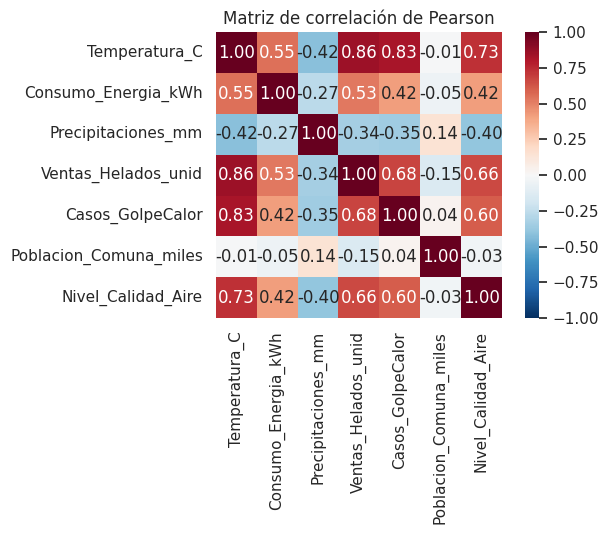

In [14]:
plt.figure(figsize=(7, 5.5))
sns.heatmap(matriz_pearson, annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1, square=True)
plt.title("Matriz de correlación de Pearson")
plt.tight_layout()
plt.show()


**Pregunta 6.1:** Mirando la matriz completa, ¿qué par de variables (dentro de las que no habían analizado en la Parte 3) tiene la correlación más fuerte? ¿Y cuál tiene la correlación más cercana a cero?

**Respuesta:** El par no analizado en la Parte 3 con la correlación más fuerte es `Temperatura_C` vs. `Ventas_Helados_unid` (r ≈ 0.86, muy fuerte), seguido muy de cerca por `Temperatura_C` vs. `Casos_GolpeCalor` (r ≈ 0.83, fuerte). El par con la correlación más cercana a cero, sin contar `Poblacion_Comuna_miles` vs. `Temperatura_C` de la Parte 3, es `Poblacion_Comuna_miles` vs. `Casos_GolpeCalor` (r ≈ 0.04): en general, `Poblacion_Comuna_miles` no muestra correlación relevante con ninguna otra variable de la matriz, lo que confirma su rol de variable de control.

## Parte 7 — Causalidad vs. correlación: detectando una relación espuria

En la Parte 3c) calcularon la correlación entre `Ventas_Helados_unid` y `Casos_GolpeCalor`. Es probable que hayan obtenido una correlación positiva y significativa.

**TODO:** calculen ahora la correlación de **cada una de esas dos variables por separado con `Temperatura_C`**.

In [15]:
r_helados_temp, p_helados_temp = stats.pearsonr(df["Ventas_Helados_unid"], df["Temperatura_C"])
r_golpecalor_temp, p_golpecalor_temp = stats.pearsonr(df["Casos_GolpeCalor"], df["Temperatura_C"])

print(f"Ventas_Helados_unid vs Temperatura_C: r = {r_helados_temp:.3f} ({interpretar_correlacion(r_helados_temp)})")
print(f"Casos_GolpeCalor    vs Temperatura_C: r = {r_golpecalor_temp:.3f} ({interpretar_correlacion(r_golpecalor_temp)})")
print(f"Ventas_Helados_unid vs Casos_GolpeCalor (de la Parte 3c): r = {r_pearson_c:.3f}")


Ventas_Helados_unid vs Temperatura_C: r = 0.859 (fuerte y positiva)
Casos_GolpeCalor    vs Temperatura_C: r = 0.828 (fuerte y positiva)
Ventas_Helados_unid vs Casos_GolpeCalor (de la Parte 3c): r = 0.676


**Pregunta 7.1:** ¿Existe una relación de causalidad directa entre las ventas de helados y los casos de golpe de calor? Si no la hay, ¿qué variable podría estar actuando como **causa común** (confounder) de ambas? Usen los tres coeficientes que acaban de calcular para justificar su respuesta.

**Respuesta:** No existe una relación de causalidad directa: no tiene sentido pensar que vender más helados provoque golpes de calor, ni que los golpes de calor provoquen más ventas de helados. Lo que ocurre es que ambas variables están fuertemente correlacionadas con `Temperatura_C` (r ≈ 0.86 y r ≈ 0.83 respectivamente, ambas "fuertes" o "muy fuertes"), mientras que la correlación entre ellas dos es más baja (r ≈ 0.68, "moderada"). Esto es exactamente el patrón esperado cuando dos variables no se causan entre sí, sino que comparten una **causa común**: la temperatura sube, y eso hace subir tanto las ventas de helados como los casos de golpe de calor de forma independiente. `Temperatura_C` es, entonces, la variable confounder que explica la asociación observada entre ambas.

**Pregunta 7.2:** Si un informe municipal recomendara "reducir la venta de helados para disminuir los casos de golpe de calor", ¿qué error estarían cometiendo?

**Respuesta:** Estarían cometiendo el error clásico de confundir correlación con causalidad: interpretar una asociación estadística como si fuera una relación de causa-efecto. Intervenir sobre `Ventas_Helados_unid` (por ejemplo, restringiendo su venta) no tendría ningún efecto sobre `Casos_GolpeCalor`, porque no existe un mecanismo causal entre ambas; lo que realmente determina los golpes de calor es la temperatura (y probablemente otros factores no incluidos en este dataset, como la exposición al sol o la hidratación de las personas), no el consumo de helados.

## Parte 8 — Síntesis final

Redacten un resumen de 150 a 250 palabras con los principales hallazgos de su análisis. Debe mencionar explícitamente:

- Qué relación(es) del dataset les parecen **causalmente creíbles** y por qué.
- La relación espuria que identificaron en la Parte 7 y su causa común.
- Al menos una decisión metodológica que tomaron (por ejemplo, elegir Spearman en vez de Pearson) y por qué.

**Respuesta:** El análisis del dataset de indicadores urbanos de verano muestra que la temperatura es la variable que más se relaciona con el resto: presenta correlaciones fuertes con el consumo energético, las ventas de helados, los casos de golpe de calor y el nivel de calidad del aire, y una correlación negativa moderada con las precipitaciones. De estas relaciones, las que resultan causalmente creíbles son temperatura-consumo energético (a mayor calor, más uso de climatización) y temperatura-golpes de calor (el calor extremo es un factor de riesgo médico directo), ya que en ambos casos existe un mecanismo físico o fisiológico razonable detrás de la asociación. En cambio, la correlación entre ventas de helados y casos de golpe de calor (r ≈ 0.68) es un caso claro de correlación espuria: ninguna de las dos variables causa a la otra, sino que ambas responden de forma independiente a un tercer factor, la temperatura, que actúa como causa común. Una decisión metodológica relevante fue usar Spearman en vez de Pearson para el par temperatura-consumo energético, ya que esta última variable contenía outliers que distorsionaban el coeficiente de Pearson (0.55) respecto al de Spearman (0.82), más robusto frente a valores extremos. En conjunto, el ejercicio confirma que una correlación fuerte nunca debe interpretarse como evidencia suficiente de causalidad sin un análisis adicional del mecanismo subyacente.

## Antes de entregar, verifiquen que:

- [x] Generaron al menos 4 diagramas de dispersión (Parte 2).
- [x] Calcularon los 4 pares de coeficientes solicitados en la Parte 3, con su justificación de por qué usaron Pearson, Spearman o Kendall en cada caso.
- [x] Clasificaron la magnitud de cada coeficiente usando `interpretar_correlacion()` (Parte 4).
- [x] Evaluaron la significancia estadística de cada coeficiente usando `evaluar_significancia()` (Parte 5).
- [x] Construyeron la matriz de correlación completa y su heatmap (Parte 6).
- [x] Identificaron y explicaron la correlación espuria del dataset, señalando su causa común (Parte 7).
- [x] Todas las celdas de markdown con `**Respuesta:**` están completas.
- [x] El notebook fue ejecutado de principio a fin sin errores (Entorno de ejecución → Ejecutar todas en Colab).